# ProChem core functionality demo

Этот notebook показывает текущий уровень проработки ядра `prochem`: модели данных, VASP I/O, склейку restart-расчетов, dataset-режим для MLIP, анализ траекторий и экспорт таблиц.

Все пути ниже можно менять под локальные расчеты. Notebook рассчитан на запуск из корня репозитория `B:\\Science\\prochem`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT, SRC

(PosixPath('/mnt/b/Science/prochem/notebooks'),
 PosixPath('/mnt/b/Science/prochem/notebooks/src'))

In [2]:
import numpy as np
import pandas as pd

from prochem.core import (
    BandStructure,
    Calculation,
    DensityOfStates,
    Structure,
    Trajectory,
    TrajectoryMergePolicy,
)
from prochem.io import parse
from prochem.io.vasp import (
    discover_structure_files,
    discover_vasprun_files,
    parse_structure_dataset,
    parse_structure_dataset_as_trajectory,
    parse_vasprun_sequence,
)
from prochem.analysis import (
    add_distance_columns,
    add_kinetic_energy_columns,
    add_velocity_columns,
    center_of_mass_dataframe,
    coordinate_dataframe,
    export_dataframe,
)
from prochem.rendering import SceneData, to_scene_data
from prochem.adapters.jupyter import scene_figure, scene_animation

print("imports ok")


imports ok


## Тестовые пути

`MAIN_VASPRUN` - одиночный `vasprun.xml`.
`DELETION_RESTART_DIR` - пример restart, где при продолжении удалялся атом.
`EXACT_RESTART_DIR` - пример restart с обычными exact overlap-сегментами.

In [5]:
MAIN_VASPRUN = Path(r"/mnt/b/Science/Calculations/VASP/Low-k/Poss_with_Ar/POSS_Ar_30_grad_20eV/vasprun.xml")
DELETION_RESTART_DIR = Path(r"/mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV")
EXACT_RESTART_DIR = Path(r"/mnt/b/Science/Calculations/VASP/MoS2/N2/Mo/MoS2_N2_30eV_parallel_Mo")

for path in [MAIN_VASPRUN, DELETION_RESTART_DIR, EXACT_RESTART_DIR]:
    print(path, "exists=", path.exists())

/mnt/b/Science/Calculations/VASP/Low-k/Poss_with_Ar/POSS_Ar_30_grad_20eV/vasprun.xml exists= True
/mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV exists= True
/mnt/b/Science/Calculations/VASP/MoS2/N2/Mo/MoS2_N2_30eV_parallel_Mo exists= True


## Базовые модели: Calculation, Trajectory, Structure

`parse()` выбирает парсер через `prochem.io.registry`. Для VASP возвращается единая модель `Calculation`.

In [7]:
calculation = parse(MAIN_VASPRUN)
trajectory = calculation.trajectory
first = trajectory.frame(0)

print(type(calculation).__name__, calculation.engine, calculation.source)
print("steps:", calculation.step_count)
print("registry atoms:", calculation.atom_count)
print("first frame atoms:", first.atom_count)
print("cell:\n", first.cell.vectors)
print("first species:", first.species[:10])
print("all species:", first.species)

Calculation vasp /mnt/b/Science/Calculations/VASP/Low-k/Poss_with_Ar/POSS_Ar_30_grad_20eV/vasprun.xml
steps: 10000
registry atoms: 32
first frame atoms: 32
cell:
 [[20.  0.  0.]
 [ 0. 20.  0.]
 [ 0.  0. 20.]]
first species: ['O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O']
all species: ['O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'O' 'Si' 'Si' 'Si' 'Si' 'Si'
 'Si' 'Si' 'Si' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'C' 'Ar']


## Плотные массивы траектории

`Trajectory` хранит список `Structure`, но умеет отдавать плотные массивы `(steps, registry_atoms, 3)`. Если атом был удален при restart, его слоты заполняются `NaN`.

In [8]:
positions = trajectory.positions_array()
direct = trajectory.direct_positions_array()
mask = trajectory.presence_mask()

print("positions:", positions.shape)
print("direct:", direct.shape)
print("presence mask:", mask.shape)
print("missing atom slots:", int((~mask).sum()))

positions: (10000, 32, 3)
direct: (10000, 32, 3)
presence mask: (10000, 32)
missing atom slots: 0


## Склейка restart-расчетов

`TrajectoryMergePolicy.boundary_search_frames` ищет overlap не только в первом кадре следующего `vasprun`, но и в первых N кадрах. Это нужно для случая, когда POSCAR был сделан из CONTCAR с оставленным блоком после скоростей: VASP может дать один или несколько стартовых кадров, которые не совпадают с концом предыдущего сегмента.

`allow_mismatch_fallback=False` запрещает fallback, при котором несовпадающий сегмент регистрируется как новые атомы. Это полезно для строгой проверки restart-склейки и для MLIP dataset workflow.

In [10]:
policy = TrajectoryMergePolicy(
    boundary_search_frames=6,
    allow_mismatch_fallback=False,
    keep_topology_change_frame=True,
)

merged, report = parse_vasprun_sequence(DELETION_RESTART_DIR, policy=policy)
for event in report.events:
    print(
        event.status,
        "next=", event.next_source.name,
        "matched=", event.matched_next_frame,
        "drop=", event.dropped_next_frames,
        "deleted=", event.deleted_atom_ids,
        "max_delta=", event.max_delta,
    )

print("merged steps:", merged.step_count)
print("registry atoms:", merged.atom_count)
print("missing slots:", int((~merged.trajectory.presence_mask()).sum()))

first next= vasprun-1837565.xml matched= 0 drop= 0 deleted= () max_delta= None
deletion_overlap next= vasprun.xml matched= 0 drop= 0 deleted= (38,) max_delta= 0.0
merged steps: 11564
registry atoms: 39
missing slots: 10000


## Analysis: координаты, скорости, энергии, расстояния

Функции из `prochem.analysis` не зависят от GUI. Их можно использовать из Qt, Jupyter и web API.

In [22]:
traj = merged.trajectory
atom_ids = [record.atom_id for record in traj.atom_registry[:3]]

df = coordinate_dataframe(traj, atom_ids=atom_ids)
df = add_velocity_columns(df, traj, atom_ids)
try:
    df = add_kinetic_energy_columns(df, traj, atom_ids)
except ValueError as exc:
    print("kinetic energy skipped:", exc)

df = add_distance_columns(df, traj, [(atom_ids[0], atom_ids[1])])
df.head()

,"Time, fs",F_1_dir_1,F_1_dir_2,F_1_dir_3,F_1_x,F_1_y,F_1_z,F_2_dir_1,F_2_dir_2,F_2_dir_3,...,F_3_x,F_3_y,F_3_z,V_F_1,V_F_2,V_F_3,E_F_1,E_F_2,E_F_3,0--1
0,0.00,0.133189,0.498628,0.368633,2.663772,4.986277,5.529493,0.071840,0.317114,0.36278,...,2.025739,4.000527,7.389778,NaN,NaN,NaN,NaN,NaN,NaN,2.192692
1,0.05,0.133194,0.498661,0.368633,2.663878,4.986615,5.529492,0.071845,0.317147,0.36278,...,2.025843,4.000866,7.389778,7.086809,7.088505,7.088799,0.049437,0.049461,0.049465,2.192692
2,0.10,0.133199,0.498695,0.368633,2.663983,4.986953,5.529490,0.071851,0.317181,0.36278,...,2.025946,4.001205,7.389778,7.086809,7.088509,7.085716,0.049437,0.049461,0.049422,2.192692
3,0.15,0.133204,0.498729,0.368633,2.664088,4.987292,5.529490,0.071856,0.317215,0.36278,...,2.026050,4.001544,7.389778,7.086801,7.088509,7.088798,0.049437,0.049461,0.049465,2.192692
4,0.20,0.133210,0.498763,0.368633,2.664194,4.987630,5.529489,0.071861,0.317249,0.36278,...,2.026154,4.001883,7.389779,7.088000,7.088509,7.088799,0.049454,0.049461,0.049465,2.192693


In [23]:
cm = center_of_mass_dataframe(traj, atom_ids, name="cm_first3")
cm.head()

,"Time, fs",cm_first3_x,cm_first3_y,cm_first3_z
0,0.00,2.042105,4.052647,6.120324
1,0.05,2.042209,4.052985,6.120323
2,0.10,2.042314,4.053324,6.120323
3,0.15,2.042418,4.053662,6.120322
4,0.20,2.042523,4.054001,6.120322


## SceneData: единый DTO для визуализации

`to_scene_data()` превращает `Structure`, `Trajectory`, `StructureDataset` или `Calculation` в backend-independent `SceneData`. Qt/OpenGL, Jupyter/Plotly и web-слой могут читать одни и те же primitives: atoms, bonds, cell, axes.


In [24]:
scene = to_scene_data(
    merged,
    frame_indices=[0, merged.step_count - 1],
    atom_colors={"Si": "#d9b36c", "O": "#e74c3c", "H": "#ffffff"},
    atom_radius_scales={"H": 0.7, "Si": 1.15},
    bond_max_lengths={"Si-O": 2.1, "O-H": 1.2},
    include_periodic_images=True,
    periodic_image_depth=1,
)

print(type(scene).__name__, scene.metadata)
print("frames:", scene.frame_count)
for frame in scene.frames:
    print(
        "frame", frame.metadata.get("frame_index"),
        "atoms", len(frame.atoms),
        "image_atoms", frame.metadata.get("image_atom_count"),
        "bonds", len(frame.bonds),
        "cell", frame.cell is not None,
    )


SceneData {'kind': 'trajectory', 'frame_indices': (0, 11563), 'step_count': 11564, 'atom_count': 39, 'source': '/mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV', 'engine': 'vasp'}
frames: 2
frame 0 atoms 39 bonds 37 cell True
frame 11563 atoms 38 bonds 35 cell True


## Web schemas: SceneData JSON contract

`SceneDataSchema` задает JSON-контракт для будущего web API и может валидировать DTO без запуска FastAPI.

In [25]:
try:
    from prochem.adapters.web.schemas import SceneDataSchema

    scene_payload = SceneDataSchema.from_scene_data(scene).model_dump(mode="json")
    {
        "name": scene_payload["name"],
        "frame_count": scene_payload["frame_count"],
        "first_frame_atoms": len(scene_payload["frames"][0]["atoms"]),
        "metadata": scene_payload["metadata"],
    }
except RuntimeError as exc:
    print(exc)


## Minimal Jupyter/Plotly adapter

`scene_figure()` строит Plotly 3D для одного frame, а `scene_animation()` добавляет slider по кадрам. Эти функции работают поверх `SceneData`, поэтому не зависят от VASP/Quantum ESPRESSO/LAMMPS напрямую.


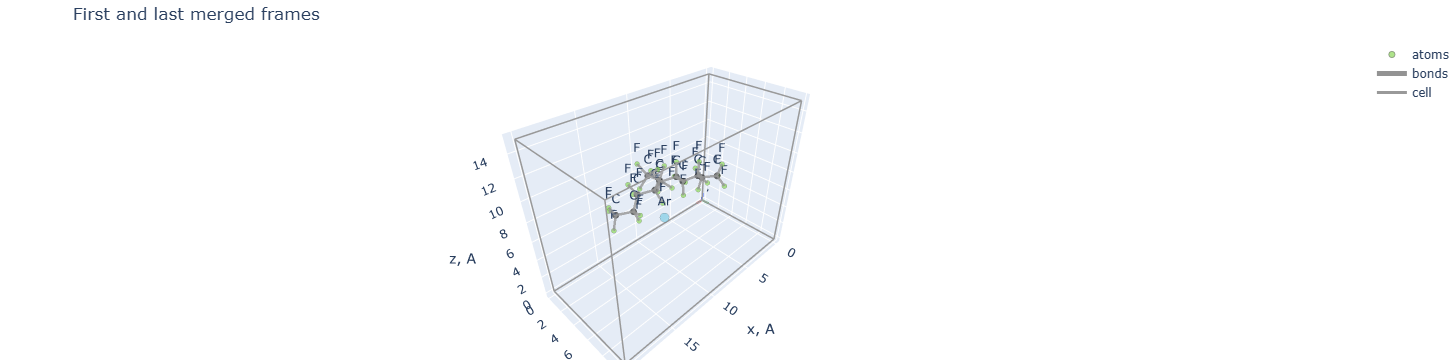

In [26]:
try:
    fig = scene_figure(scene, frame_index=0, title="First and last merged frames")
    fig.show()
except RuntimeError as error:
    print(error)
    print("Install with: pip install -e .[jupyter]")

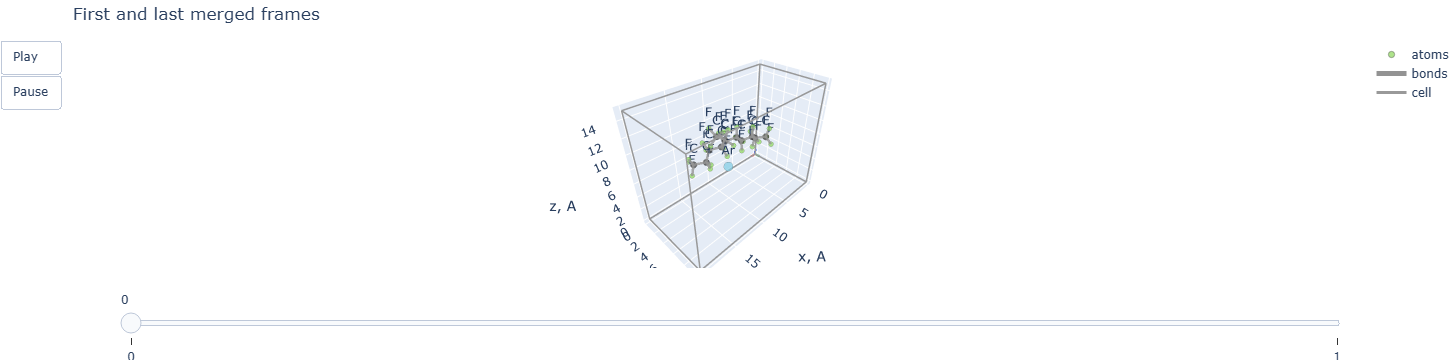

In [13]:
try:
    fig = scene_animation(scene, title="First and last merged frames")
    fig.show()
except RuntimeError as error:
    print(error)
    print("Install with: pip install -e .[jupyter]")


## Typed VASP result models

`OSZICAR`, `DOSCAR` и `EIGENVAL` теперь не раскладываются в набор разрозненных `dict`-полей. Парсер возвращает typed-модели через удобные свойства `Calculation`: `electronic_steps`, `ionic_steps`, `density_of_states`, `band_structure`. У каждой модели есть `to_dataframe()` для notebook/GUI/export сценариев.


In [27]:
vasp_result_files = {
    "OSZICAR": DELETION_RESTART_DIR / "OSZICAR",
    "DOSCAR": MAIN_VASPRUN.with_name("DOSCAR"),
    "EIGENVAL": MAIN_VASPRUN.with_name("EIGENVAL"),
}

for label, path in vasp_result_files.items():
    print(f"\n{label}: {path}")
    if not path.exists():
        print("file not found in the demo calculation")
        continue

    result = parse(path)
    if result.errors.exist:
        print(result.errors.message)
        continue

    if result.ionic_steps is not None:
        display(result.ionic_steps.to_dataframe().head())
    if result.electronic_steps is not None:
        display(result.electronic_steps.to_dataframe().head())
    if result.density_of_states is not None:
        dos = result.density_of_states
        print(type(dos).__name__, "nedos=", dos.nedos, "efermi=", dos.fermi_energy)
        display(dos.to_dataframe(shifted=True).head())
    if result.band_structure is not None:
        bands = result.band_structure
        print(type(bands).__name__, "kpoints=", bands.kpoint_count, "bands=", bands.band_count)
        display(bands.to_dataframe().head())



OSZICAR: /mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV/OSZICAR


,ionic_step,step,F,E0,T,EK,SP,SK,mag,E
0,1,1,-196.93404,-196.93383,2077.0,9.9333,0.0,0.0,1.998,-187.00076
1,2,2,-196.93764,-196.93745,2078.0,9.9369,0.0,0.0,1.999,-187.00074
2,3,3,-196.94132,-196.94115,2078.0,9.9406,0.0,0.0,1.999,-187.00074
3,4,4,-196.94509,-196.94493,2079.0,9.9443,0.0,0.0,1.999,-187.00076
4,5,5,-196.94892,-196.94877,2080.0,9.9482,0.0,0.0,1.999,-187.00076


,ionic_step,electronic_step,algorithm,energy,dE,d_eps,ncg,rms,rms_c
0,0,1,DAV,2078.228623,2078.200000,-7359.700000,1260,49.0000,NaN
1,0,2,DAV,95.806910,-1982.400000,-1836.000000,1638,16.3000,NaN
2,0,3,DAV,-188.354531,-284.160000,-281.800000,1624,6.8600,NaN
3,0,4,DAV,-192.042872,-3.688300,-3.668900,1484,0.9260,NaN
4,0,5,DAV,-192.088158,-0.045286,-0.045098,1498,0.0944,4.72



DOSCAR: /mnt/b/Science/Calculations/VASP/Low-k/Poss_with_Ar/POSS_Ar_30_grad_20eV/DOSCAR
file not found in the demo calculation

EIGENVAL: /mnt/b/Science/Calculations/VASP/Low-k/Poss_with_Ar/POSS_Ar_30_grad_20eV/EIGENVAL
BandStructure kpoints= 1 bands= 98


,kpoint_index,band_index,kx,ky,kz,weight,energy_up,energy_down,occupation_up,occupation_down
0,0,0,0.0,0.0,0.0,1.0,-25.668024,-25.675571,1.0,1.0
1,0,1,0.0,0.0,0.0,1.0,-25.265747,-25.285708,1.0,1.0
2,0,2,0.0,0.0,0.0,1.0,-25.010880,-25.017149,1.0,1.0
3,0,3,0.0,0.0,0.0,1.0,-24.967454,-24.968653,1.0,1.0
4,0,4,0.0,0.0,0.0,1.0,-24.650974,-24.633311,1.0,1.0


## MLIP dataset mode

Для датасетов структуры считаются независимыми конфигурациями, а не restart-сегментами. Поэтому используется `discover_structure_files()` / `parse_structure_dataset()` / `parse_structure_dataset_as_trajectory()`.

По умолчанию на каждую подпапку выбирается `CONTCAR`, а если его нет - `POSCAR`. При упаковке в одну trajectory включен `strict_topology=True`: если атомный состав или порядок видов отличается, функция падает вместо fallback-регистрации новых атомов.

In [28]:
structure_files = discover_structure_files(DELETION_RESTART_DIR, recursive=True)
print("found structure files:", len(structure_files))
for path in structure_files[:10]:
    print(path)

found structure files: 2
/mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV/CONTCAR
/mnt/b/Science/Calculations/VASP/ALE/C12F26/Ar/C/30eV/cont/POSCAR


In [ ]:
# Пример упаковки dataset в trajectory. Раскомментируйте на директории,
# где все структуры имеют одинаковую топологию и порядок атомов.
# dataset_calc = parse_structure_dataset_as_trajectory(DELETION_RESTART_DIR, recursive=True)
# print(dataset_calc.step_count, dataset_calc.atom_count)
# dataset_calc.trajectory.frame(0).properties

## Export

`export_dataframe()` умеет писать `.csv`, `.xlsx`, `.html`. Ниже пример CSV в локальную папку `notebooks/output`.

In [ ]:
output_dir = ROOT / "notebooks" / "output"
output_dir.mkdir(exist_ok=True)
output_path = export_dataframe(df.head(100), output_dir / "core_demo_table.csv")
output_path

## Что уже реализовано и что проверить дальше

- Готово: базовые `Calculation/Trajectory/Structure`, отдельный `StructureDataset`, VASP parser registry, restart-склейка, удаленные атомы после restart, плотные массивы с `NaN`, табличный анализ и экспорт.
- Готово по VASP-result model: `ElectronicStep/ElectronicSteps`, `IonicStep/IonicSteps`, `DensityOfStates`, `ProjectedDensityOfStates`, `BandStructure`; доступ через свойства `Calculation` и `to_dataframe()` для notebook/GUI.
- Готово по SceneData: `to_scene_data()` и специализированные конвертеры для `Structure`, `Trajectory`, `StructureDataset`, `Calculation`; primitives включают atoms, inferred bonds, cell и axes.
- Готово по Jupyter: `scene_figure()`, `scene_animation()`, `trajectory_slider()` поверх `SceneData`.
- Следующий шаг: расширить pytest-набор на restart-boundary случаи с несколькими synthetic `vasprun.xml` и добавить визуальную проверку Plotly в окружении с `prochem[jupyter]`.
